# Static predisposing variables — composite map figure (Chapter 6)

Builds a single 2x2 figure with the four static predictors aggregated to Slope Units over the whole Aburra Valley:

- **(a)** Soil type
- **(b)** Land use / land cover
- **(c)** Slope Unit type (morphometric clusters, Chapter 4)
- **(d)** Homogeneous rainfall zone (Chapter 3)

Same design rules as the Chapter 5 figure:

- no panel titles and no figure title; panels are identified only by the letters (a)-(d) and described in the LaTeX caption;
- legend inside each panel, lower right;
- frame (spines) on all four sides;
- geographic coordinates (lat/lon) labelled only on the left and bottom axes;
- the slope units carry no outline of their own, so the units along the border look exactly like the ones inside;
- the only line drawn on the map is the administrative boundary of the Aburra Valley Metropolitan Area (`amva.geojson`);
- everything in English.

---

## Dos cosas que verifiqué en tus datos antes de escribir esto

**1. El archivo correcto es `slope_units_final_mm.gpkg`, no `slope_units_final.gpkg`.**

| | `slope_units_final.gpkg` | `slope_units_final_mm.gpkg` |
|---|---|---|
| Filas | 61,242 | **61,073** |
| Niveles de `su_type` | **1, 2, 3 y 4** | **1, 2, 3** |
| Filas sin NA en las 4 variables | 60,923 | **60,914** |

El que me indicaste tiene una versión anterior del *clustering*, con **cuatro** tipos de slope unit
(el tipo 4 son 11,866 unidades). Tu diccionario `SU_LABELS` solo tiene tres etiquetas, así que
esas 11,866 unidades saldrían en blanco en el panel (c). El archivo `_mm` tiene exactamente los tres
tipos de tu diccionario, las 61,073 unidades que citas en la tesis, y 60,914 sin NA, que es
justo el número de slope units de tu tabla de clases de susceptibilidad.

**2. El diccionario `name_to_cluster` que me pasaste no coincide con la geografía.**

Calculé la posición media de cada zona en el GeoPackage (CRS 3116, así que Y crece hacia el norte):

| `zona_lluvia` | n | X medio | Y medio | Posición |
|---|---|---|---|---|
| 2 | 29,685 | 848,050 | 1,198,584 | la más al norte |
| 5 | 8,490 | 824,909 | 1,187,630 | occidente, centro-norte |
| 4 | 2,606 | 822,457 | 1,180,840 | la más al oeste, al sur |
| 1 | 5,771 | 840,049 | 1,179,656 | oriente del valle central |
| 3 | 14,383 | 829,369 | 1,166,155 | la más al sur |

Con tu diccionario (`Sur:1, Sap:2, Occidente:3, Oriente:4, Norte:5`) la zona 2 —la más
septentrional y la más extensa, con casi 30,000 unidades— quedaría etiquetada como
**San Antonio de Prado**, que es un corregimiento pequeño del suroccidente. No cuadra.

El mapeo que sí cuadra con la geografía es el de los nombres de tus figuras del Capítulo 5
(`fig_umbrales_por_enso_tipo1_zona1_Oriente.png`, `zona2_Norte`, `zona3_Sur`, `zona4_SAP`,
`zona5_Occidente`):

```
1 -> Oriente     2 -> Norte     3 -> Sur     4 -> San Antonio de Prado     5 -> Occidente
```

Es el que usa este notebook, y la **sección 4** vuelve a comprobarlo automáticamente cada vez
que lo corres. Si el resultado te sorprende, revisa el mapa del Capítulo 3 antes de seguir:
una leyenda de zonas mal asignada invalida el panel (d) y, peor, los efectos por zona del GAM.

## 1. Libraries and global settings

In [10]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ---------------------------------------------------------------- settings
# IMPORTANTE: este es el GeoPackage con los TRES tipos de slope unit y las
# 61,073 unidades. No uses 'slope_units_final.gpkg' (ver nota de arriba).
PATH_SU     = '/home/oisanchezp/Thesis/src/05_Chapter/slope_units_final_mm.gpkg'
PATH_AMVA   = '/home/oisanchezp/Thesis/data/metadata/amva.geojson'          # ajusta la ruta si lo tienes en otra carpeta
OUT_DIR     = Path('00Figuras/06Seccion')
OUT_NAME    = 'fig_static_variables_cap6'

CRS_PLOT    = 'EPSG:4326'   # geographic CRS, so ticks are in degrees
SIMPLIFY_M  = 5             # simplification for DRAWING only (metres); 0 = off
EDGECOLOR   = 'none'        # no outline on the slope units themselves

DRAW_AMVA   = True          # draw the metropolitan-area boundary
AMVA_LW     = 0.8
AMVA_COLOR  = 'black'

DROP_EMPTY_CLASSES = True   # hide classes with zero units from the legends

# Dibujar solo las unidades que entraron a los modelos (sin NA en las cuatro
# variables). True = la figura muestra exactamente el universo modelado, que
# es lo coherente con Results. False = muestra las 61,073 delimitadas y los
# huecos aparecen en blanco en los paneles (b) y (d).
ONLY_MODELLED = True

# Paleta de las zonas de lluvia:
#   'chapter3' -> los colores C0..C4 de matplotlib, los mismos del Capítulo 3.
#                 Ventaja: el lector reconoce las zonas entre capítulos.
#                 Desventaja: no es segura para daltonismo y su naranja se
#                 parece al del tipo 1 de slope unit del panel (c).
#   'cb_safe'  -> paleta Paul Tol bright, segura para daltonismo y bien
#                 diferenciada de los colores del panel (c).
ZONE_PALETTE = 'chapter3'

# Añadir el código numérico a la etiqueta de la zona ('2 - Norte' en vez de
# 'Norte'). Útil si quieres que el mapa se lea junto a las tablas del modelo,
# donde la zona aparece como nivel del factor.
SHOW_ZONE_CODE = False

OUT_DIR.mkdir(parents=True, exist_ok=True)
print('geopandas', gpd.__version__)
import shapely; print('shapely  ', shapely.__version__)

geopandas 1.1.4
shapely   2.1.2


## 2. Load the Slope Units

The relevant columns are `suelos`, `cobertura_cat`, `su_type` and `zona_lluvia`.

In [3]:
pip install geopandas shapely fiona

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fiona: filename=fiona-1.10.1-cp314-cp314-linux_x86_64.whl size=6063770 sha256=5b7d796584c41028fd3d85a5ea917dad2a5a741163d3254bb249c98ee678e1db
  Stored in directory: /home/oisanchezp/.cache/pip/wheels/3c/3e/56/f0e7dc93d0c0f5d2725b85aac3443c34ebc090c73bce308f16
Successfully built fiona
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [fiona]32m4/5 [fiona]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# list the layers of the GeoPackage (in case there is more than one)
try:
    from pyogrio import list_layers
    print('Layers:', list_layers(PATH_SU))
except Exception:
    import fiona
    print('Layers:', fiona.listlayers(PATH_SU))

su = gpd.read_file(PATH_SU)

print(f'\nSlope Units : {len(su):,}')
print(f'CRS         : {su.crs}')
print(f'Columns     : {list(su.columns)}')
if su.crs is not None and su.crs.is_projected:
    print(f'Area (km2)  : {su.area.sum()/1e6:,.1f}')

Layers: [['slope_units_final_mm' 'MultiPolygon']]

Slope Units : 61,073
CRS         : EPSG:3116
Columns     : ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'cobertura_cat', 'cobertura', 'n_mm', 'si_no', 'suelos', 'zona_lluvia', 'curva_std_mean', 'curva_std_std', 'cluster_prob', 'geometry']
Area (km2)  : 1,004.5


In [5]:
# ---- DIAGNOSTIC: check the raw values before mapping them to English labels
VARS = ['suelos', 'cobertura_cat', 'su_type', 'zona_lluvia']

for col in VARS:
    print(f'--- {col} (dtype: {su[col].dtype}) ---')
    print(su[col].value_counts(dropna=False).to_string(), '\n')

print('NaN per column:')
print(su[VARS].isna().sum().to_string())

n_total = len(su)
n_model = int(su[VARS].notna().all(axis=1).sum())
print(f'\nDelineated slope units          : {n_total:,}')
print(f'Complete in the four variables  : {n_model:,}')
print(f'Dropped because of missing data : {n_total - n_model:,}')
print('\nEste ultimo par de numeros es el que debe aparecer en la seccion Data '
      'del capitulo. Si no coincide con lo que ya escribiste, corrige el texto, '
      'no el codigo.')

--- suelos (dtype: str) ---
suelos
Areno-limoso                       23284
Areno-arcilloso                    17161
Bloques, gravas, arenas y lodos    11751
Limo-arcilloso                      8877 

--- cobertura_cat (dtype: float64) ---
cobertura_cat
3.0    27176
2.0    17767
1.0    11854
0.0     3744
4.0      437
NaN       95 

--- su_type (dtype: int64) ---
su_type
1    31594
2    22912
3     6567 

--- zona_lluvia (dtype: float64) ---
zona_lluvia
2.0    29685
3.0    14383
5.0     8490
1.0     5771
4.0     2606
NaN      138 

NaN per column:
suelos             0
cobertura_cat     95
su_type            0
zona_lluvia      138

Delineated slope units          : 61,073
Complete in the four variables  : 60,914
Dropped because of missing data : 159

Este ultimo par de numeros es el que debe aparecer en la seccion Data del capitulo. Si no coincide con lo que ya escribiste, corrige el texto, no el codigo.


In [6]:
# ---- quedarse solo con las unidades modeladas, si asi se pidio
if ONLY_MODELLED:
    before = len(su)
    su = su[su[VARS].notna().all(axis=1)].copy()
    print(f'Filtered to modelled units: {before:,} -> {len(su):,}')
else:
    print(f'Keeping all {len(su):,} delineated units (panels b and d will have gaps).')

Filtered to modelled units: 61,073 -> 60,914


## 3. Category labels in English

`cobertura` may come either as numeric codes (0-4) or as the original Spanish strings; both
cases are handled, exactly as in the Chapter 5 notebook. `su_type` and `zona_lluvia` are
numeric codes and are mapped through explicit dictionaries.

In [15]:
# --- land cover -----------------------------------------------------------
COVER_FROM_CODE = {
    0: 'Continuous urban fabric',
    1: 'Discontinuous urban fabric',
    2: 'Agricultural areas',
    3: 'Forests',
    4: 'Bare and degraded land',
}
COVER_FROM_ES = {
    'Tejido urbano continuo':        'Continuous urban fabric',
    'Tejido urbano discontinuo':     'Discontinuous urban fabric',
    'Territorios agricolas':         'Agricultural areas',
    'Territorios agrícolas':    'Agricultural areas',
    'Tierras agricolas':             'Agricultural areas',
    'Tierras agrícolas':        'Agricultural areas',
    'Bosques':                       'Forests',
    'Tierras desnudas y degradadas': 'Bare and degraded land',
}

# --- soil type ------------------------------------------------------------
SOIL_FROM_ES = {
    'Limo-arcilloso':                  'Silty clay',
    'Areno-arcilloso':                 'Sandy clay',
    'Areno-limoso':                    'Sandy silt',
    'Bloques, gravas, arenas y lodos': 'Blocks, gravel, sand and mud',
}

# --- slope unit type (Chapter 4) -----------------------------------------
SU_LABELS = {
    1: 'Steep concave–convex slopes',
    2: 'Intermediate concave–convex slopes',
    3: 'Steep concave slopes',
}
SU_COLORS = {1: '#E69F00', 2: '#009E73', 3: '#D81B60'}   # Okabe-Ito

# --- homogeneous rainfall zone (Chapter 3) -------------------------------
# Mapeo verificado contra la posicion geografica de cada zona (ver seccion 4).
ZONE_LABELS = {
    1: 'Oriente',
    2: 'Norte',
    3: 'Sur',
    4: 'San Antonio de Prado',
    5: 'Occidente',
}
# Alternativa si prefieres toponimos traducidos en un texto en ingles.
# Recomiendo NO usarla: son nombres propios de sectores del valle y en el
# Capitulo 3 quedaron en espanol; traducirlos rompe la correspondencia.
ZONE_LABELS_EN = {
    1: 'East', 2: 'North', 3: 'South',
    4: 'San Antonio de Prado', 5: 'West',
}

# C0..C4 de matplotlib, los del Capitulo 3 (asumiendo cluster 1 -> C0).
# VERIFICA esta correspondencia contra la figura del Capitulo 3.
ZONE_COLORS_CH3 = {
    1: '#d62728',   # Oriente              -> rojo    (C3)
    2: '#9467bd',   # Norte                -> morado  (C4)
    3: '#1f77b4',   # Sur                  -> azul    (C0)
    4: '#ff7f0e',   # San Antonio de Prado -> naranja (C1)
    5: '#2ca02c',   # Occidente            -> verde   (C2)
}
# Paul Tol bright: segura para daltonismo y distinta de SU_COLORS.
ZONE_COLORS_CB  = {1: '#4477AA', 2: '#EE6677', 3: '#228833',
                   4: '#CCBB44', 5: '#66CCEE'}

ZONE_COLORS = ZONE_COLORS_CH3 if ZONE_PALETTE == 'chapter3' else ZONE_COLORS_CB
print(f'Rainfall-zone palette: {ZONE_PALETTE}')


def to_english(series, from_code=None, from_es=None):
    """Translate a categorical column to English, whether it is numeric or text."""
    if pd.api.types.is_numeric_dtype(series) and from_code is not None:
        return series.map(lambda v: from_code.get(int(v)) if pd.notna(v) else np.nan)
    s = series.astype(str).str.strip()
    s = s.where(series.notna(), np.nan)
    return s.map(from_es)


def to_label_from_code(series, mapping):
    """Map a numeric (or numeric-as-text) code column to labels."""
    if pd.api.types.is_numeric_dtype(series):
        return series.map(lambda v: mapping.get(int(v)) if pd.notna(v) else np.nan)
    # columna de texto: puede traer ya el nombre, o el numero como cadena
    s = series.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce').map(
        lambda v: mapping.get(int(v)) if pd.notna(v) else np.nan)
    # lo que no era numero, se intenta casar con los nombres (sin importar
    # mayusculas ni acentos sueltos como 'Sap' / 'SAP')
    canon = {str(v).strip().lower(): v for v in mapping.values()}
    canon.update({'sap': mapping.get(4, 'San Antonio de Prado')})
    fallback = s.str.lower().map(canon)
    return out.fillna(fallback).where(series.notna(), np.nan)


su['soil_en']  = to_english(su['suelos'], None, SOIL_FROM_ES)
su['cover_en'] = to_english(su['cobertura_cat'], COVER_FROM_CODE, COVER_FROM_ES)
su['su_en']    = to_label_from_code(su['su_type'], SU_LABELS)
su['zone_en']  = to_label_from_code(su['zona_lluvia'], ZONE_LABELS)

if SHOW_ZONE_CODE:
    code_of = {v: k for k, v in ZONE_LABELS.items()}
    su['zone_en'] = su['zone_en'].map(
        lambda v: f'{code_of[v]} – {v}' if pd.notna(v) else v)

# report any value that failed to map (excluding genuine NaN in the source)
for src, dst in [('suelos', 'soil_en'), ('cobertura_cat', 'cover_en'),
                 ('su_type', 'su_en'), ('zona_lluvia', 'zone_en')]:
    bad = su.loc[su[dst].isna() & su[src].notna(), src].unique()
    if len(bad):
        print(f'WARNING - unmapped values in "{src}": {bad}')
    else:
        print(f'OK - all values of "{src}" were mapped.')

Rainfall-zone palette: chapter3
OK - all values of "suelos" were mapped.
OK - all values of "cobertura_cat" were mapped.
OK - all values of "su_type" were mapped.
OK - all values of "zona_lluvia" were mapped.


## 4. Sanity check of the rainfall-zone labels

Una etiqueta de zona mal asignada no produce ningún error: produce un mapa bonito y
equivocado, y arrastra el problema hasta los efectos por zona del GAM. Esta celda vuelve a
comprobar, con la geometría, que los nombres caen donde deben:

- **Norte** debe ser la zona con el centroide más septentrional;
- **Sur**, la más meridional;
- **San Antonio de Prado**, la más occidental y pequeña.

`Oriente` y `Occidente` no se pueden verificar solo con la coordenada X, porque el valle se
alarga hacia el nororiente y eso hace que la zona Norte también sea la de mayor X. Para esas
dos, la celda compara únicamente entre las zonas del valle central.

Si alguna comprobación falla, **no sigas**: revisa el mapa del Capítulo 3 y corrige
`ZONE_LABELS` antes de generar la figura.

In [8]:
cen = su.copy()
if cen.crs is not None and cen.crs.is_geographic:
    cen = cen.to_crs('EPSG:3116')          # metros, Y crece al norte
cen['cx'] = cen.geometry.centroid.x
cen['cy'] = cen.geometry.centroid.y

chk = (cen.groupby('zone_en')
          .agg(n=('cx', 'size'), x_mean=('cx', 'mean'), y_mean=('cy', 'mean'))
          .sort_values('y_mean', ascending=False))
print(chk.to_string(float_format=lambda v: f'{v:,.0f}'), '\n')

ok = True

def check(msg, condition):
    global ok
    print(('PASS  ' if condition else 'FAIL  ') + msg)
    ok = ok and condition

north = chk['y_mean'].idxmax()
south = chk['y_mean'].idxmin()
west  = chk['x_mean'].idxmin()

check(f'la zona mas al norte es "{north}"  (se espera Norte)',
      'Norte' in str(north) or 'North' in str(north))
check(f'la zona mas al sur es "{south}"  (se espera Sur)',
      'Sur' in str(south) or 'South' in str(south))
check(f'la zona mas al oeste es "{west}"  (se espera San Antonio de Prado)',
      'Prado' in str(west))

# Oriente vs Occidente, solo entre las zonas del valle central
central = chk.drop(index=[i for i in chk.index if 'Norte' in str(i) or 'North' in str(i)],
                   errors='ignore')
if len(central) >= 2:
    east_c = central['x_mean'].idxmax()
    check(f'entre las zonas del valle central, la mas oriental es "{east_c}"  '
          f'(se espera Oriente)',
          'Oriente' in str(east_c) or 'East' in str(east_c))

print('\n' + ('Todo cuadra: los nombres de zona son coherentes con la geografia.'
              if ok else
              'ALGO NO CUADRA. Revisa ZONE_LABELS contra el mapa del Capitulo 3 '
              'ANTES de generar la figura.'))

                          n  x_mean    y_mean
zone_en                                      
Norte                 29676 848,044 1,198,583
Occidente              8490 824,909 1,187,630
San Antonio de Prado   2606 822,457 1,180,840
Oriente                5768 840,048 1,179,658
Sur                   14374 829,373 1,166,160 

PASS  la zona mas al norte es "Norte"  (se espera Norte)
PASS  la zona mas al sur es "Sur"  (se espera Sur)
PASS  la zona mas al oeste es "San Antonio de Prado"  (se espera San Antonio de Prado)
PASS  entre las zonas del valle central, la mas oriental es "Oriente"  (se espera Oriente)

Todo cuadra: los nombres de zona son coherentes con la geografia.


## 5. Geometry preparation

The slope units are not dissolved: the only line on the map is the administrative boundary of
the Aburra Valley Metropolitan Area, read from `amva.geojson`. This keeps the units along the
border looking exactly like the ones inside.

Geometries are simplified (for drawing only, never for analysis) and reprojected to
`EPSG:4326` so that the axis ticks are latitude and longitude.

In [11]:
# ---- 1) metropolitan-area boundary ---------------------------------------
amva = None
if DRAW_AMVA:
    amva = gpd.read_file(PATH_AMVA)
    print(f'AMVA features: {len(amva)} | CRS: {amva.crs}')
    amva = amva.to_crs(su.crs).dissolve()          # single polygon
    amva = amva.to_crs(CRS_PLOT).geometry
    print('AMVA boundary ready.')

# ---- 2) slope units: simplify for drawing, then reproject ----------------
su_plot = su.copy()
if SIMPLIFY_M and su_plot.crs is not None and su_plot.crs.is_projected:
    su_plot['geometry'] = su_plot.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
su_plot = su_plot.to_crs(CRS_PLOT)

# ---- 3) common extent: slope units and boundary together -----------------
b = su_plot.total_bounds
if amva is not None:
    a = amva.total_bounds
    b = [min(b[0], a[0]), min(b[1], a[1]), max(b[2], a[2]), max(b[3], a[3])]
XMIN, YMIN, XMAX, YMAX = b
PADX = (XMAX - XMIN) * 0.01
PADY = (YMAX - YMIN) * 0.03

print(f'Plot CRS: {su_plot.crs.to_string()}')
print(f'Bounds  : lon {XMIN:.3f} to {XMAX:.3f} | lat {YMIN:.3f} to {YMAX:.3f}')

AMVA features: 1 | CRS: EPSG:4326
AMVA boundary ready.
Plot CRS: EPSG:4326
Bounds  : lon -75.719 to -75.221 | lat 5.978 to 6.512


## 6. Panel helper

One function draws one categorical map with the required styling: no title, a letter label in
the upper-left corner, legend in the lower right, frame on all four sides, and tick labels only
on the left and bottom. It is the same helper as in the Chapter 5 notebook, unchanged.

In [12]:
def fmt_lon(x, _):
    hemi = 'W' if x < 0 else 'E'
    return f'{abs(x):.2f}° {hemi}'


def fmt_lat(y, _):
    hemi = 'S' if y < 0 else 'N'
    return f'{abs(y):.2f}° {hemi}'


def add_panel(ax, gdf, column, categories, colors, label, legend_title,
              legend_loc='lower right', ncol=1, ylabel_rotation=90):
    """Draw one categorical Slope-Unit map into `ax`.

    The slope units are drawn without any edge colour, so the units on the
    border of the study area look identical to the ones inside. The only
    line on the map is the AMVA administrative boundary.
    """
    for cat, col in zip(categories, colors):
        sub = gdf[gdf[column] == cat]
        if len(sub) == 0:
            continue
        sub.plot(ax=ax, color=col, edgecolor=EDGECOLOR, linewidth=0.0, zorder=2)

    if amva is not None:
        amva.boundary.plot(ax=ax, color=AMVA_COLOR, linewidth=AMVA_LW, zorder=5)

    # legend, optionally hiding classes with no units
    pairs = list(zip(categories, colors))
    if DROP_EMPTY_CLASSES:
        pairs = [(c, k) for c, k in pairs if (gdf[column] == c).any()]
    handles = [Patch(facecolor=k, edgecolor='0.35', linewidth=0.4, label=c)
               for c, k in pairs]
    leg = ax.legend(handles=handles, title=legend_title, loc=legend_loc,
                    frameon=True, framealpha=0.95, edgecolor='0.45',
                    ncol=ncol, borderpad=0.6, handlelength=1.3,
                    handleheight=1.0, labelspacing=0.35)
    leg.get_frame().set_linewidth(0.6)
    leg.set_zorder(10)
    leg._legend_box.align = 'left'

    # identical extent in the four panels
    ax.set_xlim(XMIN - PADX, XMAX + PADX)
    ax.set_ylim(YMIN - PADY, YMAX + PADY)

    # frame on all four sides
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.8)
        sp.set_color('black')

    # ticks and labels only on the left and bottom
    ax.tick_params(which='both', direction='out', length=3, width=0.7,
                   top=False, right=False, labeltop=False, labelright=False,
                   bottom=True, left=True, labelbottom=True, labelleft=True,
                   labelsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune='both'))
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
    ax.tick_params(axis='y', rotation=ylabel_rotation)
    for t in ax.get_yticklabels():
        t.set_va('center')
    ax.set_xlabel('')
    ax.set_ylabel('')

    # panel letter, no title
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, fontweight='bold', zorder=10,
            bbox=dict(boxstyle='square,pad=0.30', facecolor='white',
                      edgecolor='0.45', linewidth=0.6))
    return ax

## 7. Composite figure

Drawing 61,000 polygons four times takes a couple of minutes the first time.

El orden de las categorías en cada leyenda no es casual: en (a) los suelos van de más fino a
más grueso, en (b) la cobertura va de natural a urbana, y en (c) y (d) se respeta el orden de
los códigos, que es el mismo con el que las variables entran al modelo. Así la leyenda del
mapa se lee junto a la tabla de razones de tasa sin reordenar nada mentalmente.

Saved to: 00Figuras/06Seccion/fig_static_variables_cap6.png


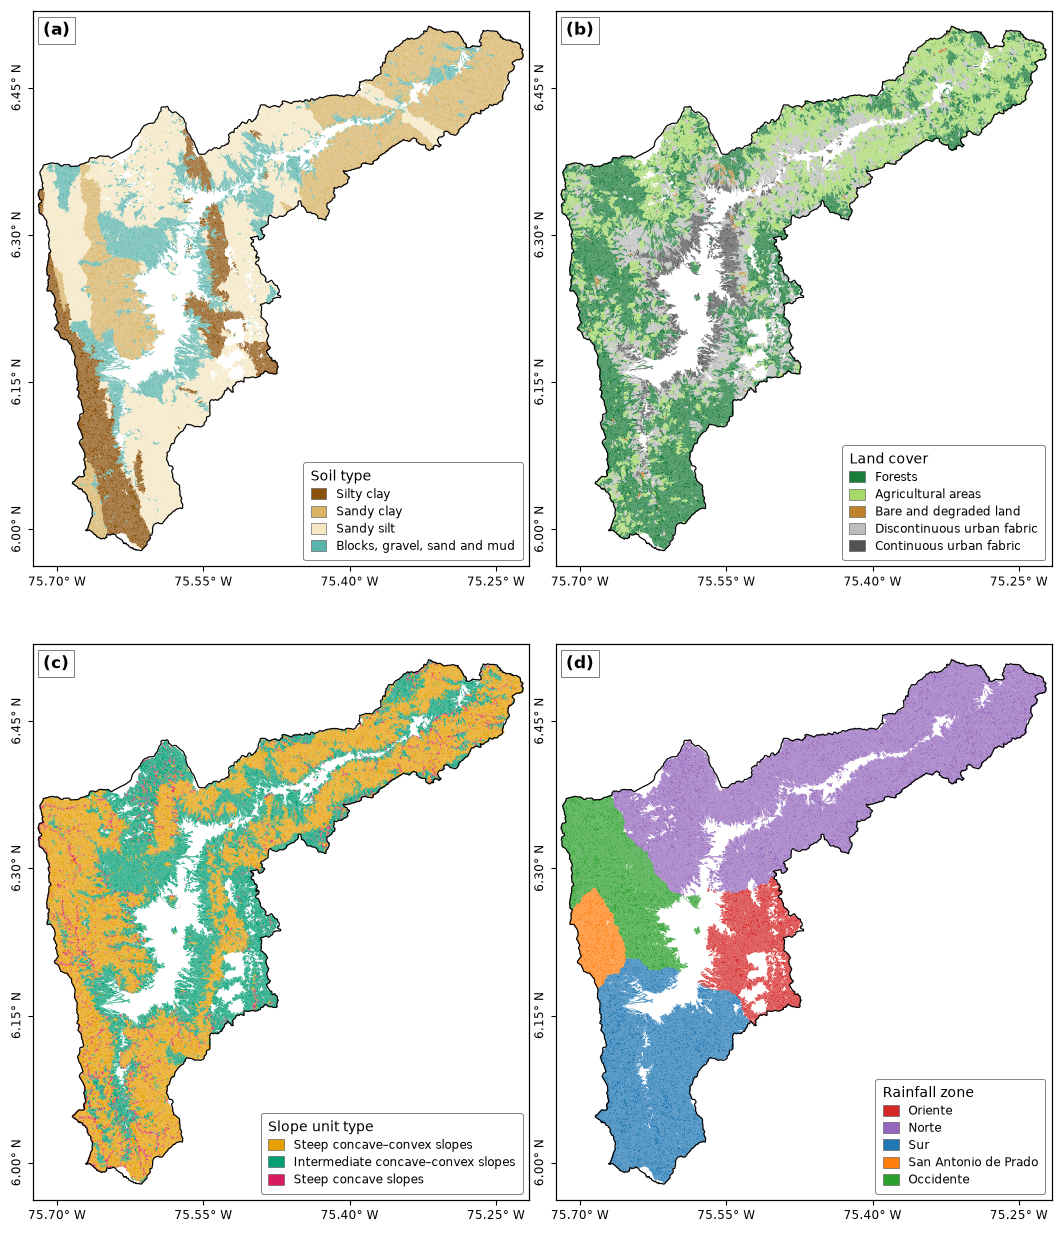

In [16]:
SOIL_CATS = ['Silty clay', 'Sandy clay', 'Sandy silt', 'Blocks, gravel, sand and mud']
SOIL_COLS = ['#8c510a', '#d8b365', '#f6e8c3', '#5ab4ac']

COVER_CATS = ['Forests', 'Agricultural areas', 'Bare and degraded land',
              'Discontinuous urban fabric', 'Continuous urban fabric']
COVER_COLS = ['#1a7c3a', '#a6d96a', '#bf812d', '#bdbdbd', '#525252']

SU_CATS = [SU_LABELS[k] for k in sorted(SU_LABELS)]
SU_COLS = [SU_COLORS[k] for k in sorted(SU_COLORS)]

_zone_name = (lambda k: f'{k} – {ZONE_LABELS[k]}') if SHOW_ZONE_CODE \
             else (lambda k: ZONE_LABELS[k])
ZONE_CATS = [_zone_name(k) for k in sorted(ZONE_LABELS)]
ZONE_COLS = [ZONE_COLORS[k] for k in sorted(ZONE_LABELS)]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 11.5), constrained_layout=True)

fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02,
                                wspace=0.01, hspace=0.01)

add_panel(axes[0, 0], su_plot, 'soil_en',  SOIL_CATS,  SOIL_COLS,
          '(a)', 'Soil type')

add_panel(axes[0, 1], su_plot, 'cover_en', COVER_CATS, COVER_COLS,
          '(b)', 'Land cover')

add_panel(axes[1, 0], su_plot, 'su_en',    SU_CATS,    SU_COLS,
          '(c)', 'Slope unit type')

add_panel(axes[1, 1], su_plot, 'zone_en',  ZONE_CATS,  ZONE_COLS,
          '(d)', 'Rainfall zone')

fig.savefig(OUT_DIR / f'{OUT_NAME}.png')
fig.savefig(OUT_DIR / f'{OUT_NAME}.pdf')
print('Saved to:', OUT_DIR / f'{OUT_NAME}.png')
plt.show()

## 8. Summary table for the text

Number of Slope Units and percentage per class. Esta tabla es la que alimenta la
Tabla de niveles de la sección Data del Capítulo 6, y sirve además para detectar
**separación completa**: si alguna categoría tiene muchas unidades y ningún deslizamiento
observado, su coeficiente en el ZINB se irá al infinito. Por eso la última columna
cuenta las unidades con `n_mm > 0`.

In [14]:
has_counts = 'n_mm' in su.columns

blocks = [('Soil type',       'soil_en',  SOIL_CATS),
          ('Land cover',      'cover_en', COVER_CATS),
          ('Slope unit type', 'su_en',    SU_CATS),
          ('Rainfall zone',   'zone_en',  ZONE_CATS)]

rows = []
for var, col, cats in blocks:
    counts = su[col].value_counts().reindex(cats, fill_value=0)
    for cat, n in counts.items():
        rec = {'Variable': var, 'Class': cat, 'Units': int(n),
               'Percent': round(100 * n / len(su), 1)}
        if has_counts:
            sub = su.loc[su[col] == cat, 'n_mm']
            rec['Units with landslides'] = int((sub > 0).sum())
            rec['Landslides'] = int(sub.sum())
        rows.append(rec)

summary = pd.DataFrame(rows)
summary = summary[summary['Units'] > 0].reset_index(drop=True)
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / 'static_variables_cap6_summary.csv', index=False)

if has_counts:
    empty = summary[summary['Units with landslides'] == 0]
    if len(empty):
        print('\nAVISO - categorias SIN ningun deslizamiento observado '
              '(riesgo de separacion completa en el ZINB):')
        print(empty[['Variable', 'Class', 'Units']].to_string(index=False))
        print('Agrupa esos niveles con el mas parecido, o reportalos '
              'explicitamente en el texto.')
    else:
        print('\nOK - todas las categorias tienen al menos un deslizamiento observado.')

       Variable                              Class  Units  Percent  Units with landslides  Landslides
      Soil type                         Silty clay   8862     14.5                    727        1110
      Soil type                         Sandy clay  17125     28.1                   1316        2151
      Soil type                         Sandy silt  23196     38.1                   1411        2001
      Soil type       Blocks, gravel, sand and mud  11731     19.3                    606         936
     Land cover                            Forests  27148     44.6                   1941        2958
     Land cover                 Agricultural areas  17740     29.1                   1123        1738
     Land cover             Bare and degraded land    437      0.7                     31          47
     Land cover         Discontinuous urban fabric  11845     19.4                    712        1113
     Land cover            Continuous urban fabric   3744      6.1                

## 9. LaTeX snippet

```latex
\begin{figure}[!ht]
    \centering
    \includegraphics[width=0.90\textwidth]{00Figuras/06Seccion/fig_static_variables_cap6.pdf}
    \caption{Static predisposing variables aggregated to the $60{,}914$ slope units used in
    this chapter: (a) soil type; (b) land use and land cover; (c) morphometric type of slope
    unit, derived from the clustering of slope, curvature and aspect in
    Chapter~\ref{chapter_4}; and (d) homogeneous rainfall zone, delineated in
    Chapter~\ref{chapter_3}. Categorical variables were assigned the class covering the
    largest area within each polygon. Soil type and land cover are the two predictors
    retained from Chapter~\ref{chapter_5}; slope unit type and rainfall zone are introduced
    here. The black line is the boundary of the Aburr\'a Valley Metropolitan Area.}
    \label{fig:th-static4}
\end{figure}
```

Ajusta el número de unidades del caption según lo que hayas puesto en `ONLY_MODELLED`:
60,914 si es `True`, 61,073 si es `False`.